# Análise de dados com Pandas e Seaborn

A base de dados utilizada aqui é de churn de clientes de uma empresa de telecomunicações. O churn é uma métrica que indica a taxa de evasão de clientes. Neste caso, o churn é definido como a perda de clientes para a concorrência ou por desinteresse em continuar com o serviço. O objetivo é analisar os dados e identificar os principais fatores que levam um cliente a cancelar o serviço.

Temos o seguinte dicionário de dados:

- `id_cliente`: identificador único do cliente
- `genero`: gênero do cliente
- `idoso`: indica se o cliente é idoso (mais de 65 anos) ou não
- `tem_parceiro`: indica se o cliente tem parceiro ou não
- `tem_dependentes`: indica se o cliente tem dependentes ou não
- `meses_na_empresa`: quantidade de meses que o cliente permaneceu na empresa
- `servico_telefone`: indica se o cliente tem serviço de telefone ou não
- `multiplas_linhas`: indica se o cliente tem múltiplas linhas ou não
- `servico_internet`: indica se o cliente tem serviço de internet (DSL ou fibra óptica) ou não
- `servico_seguranca`: indica se o cliente tem serviço de segurança online ou não
- `servico_backup`: indica se o cliente tem serviço de backup online ou não
- `servico_protecao_equipamento`: indica se o cliente tem serviço de proteção do equipamento de conexão ou não
- `servico_suporte_tecnico`: indica se o cliente tem serviço de suporte técnico prioritário ou não
- `streaming_tv`: indica se o cliente tem serviço de streaming de TV ou não
- `streaming_filmes`: indica se o cliente tem serviço de streaming de filmes ou não
- `contrato`: tipo de contrato do cliente (mensal, anual ou dois anos)
- `fatura_digital`: indica se o cliente recebe a fatura por e-mail ou não
- `forma_pagamento`: forma de pagamento do cliente (cheque, boleto, transferência bancária ou cartão de crédito)
- `valor_mensal`: valor mensal do serviço contratado
- `total_gasto`: valor total gasto pelo cliente
- `churn`: indica se o cliente cancelou o serviço no mês anterior ou não



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='dark', palette='bright', context='notebook')

ARQUIVO_DADOS = 'churn_clientes.csv'

df_churn = pd.read_csv(ARQUIVO_DADOS)
df_churn = df_churn.drop(columns='id_cliente')


colunas_numericas = df_churn.select_dtypes(include='number').columns
colunas_categoricas = df_churn.select_dtypes(exclude='number').columns
colunas_categoricas = colunas_categoricas.drop('churn')

df_churn.head()

## Variáveis categóricas


### Análise dos percentuais de churn por categoria

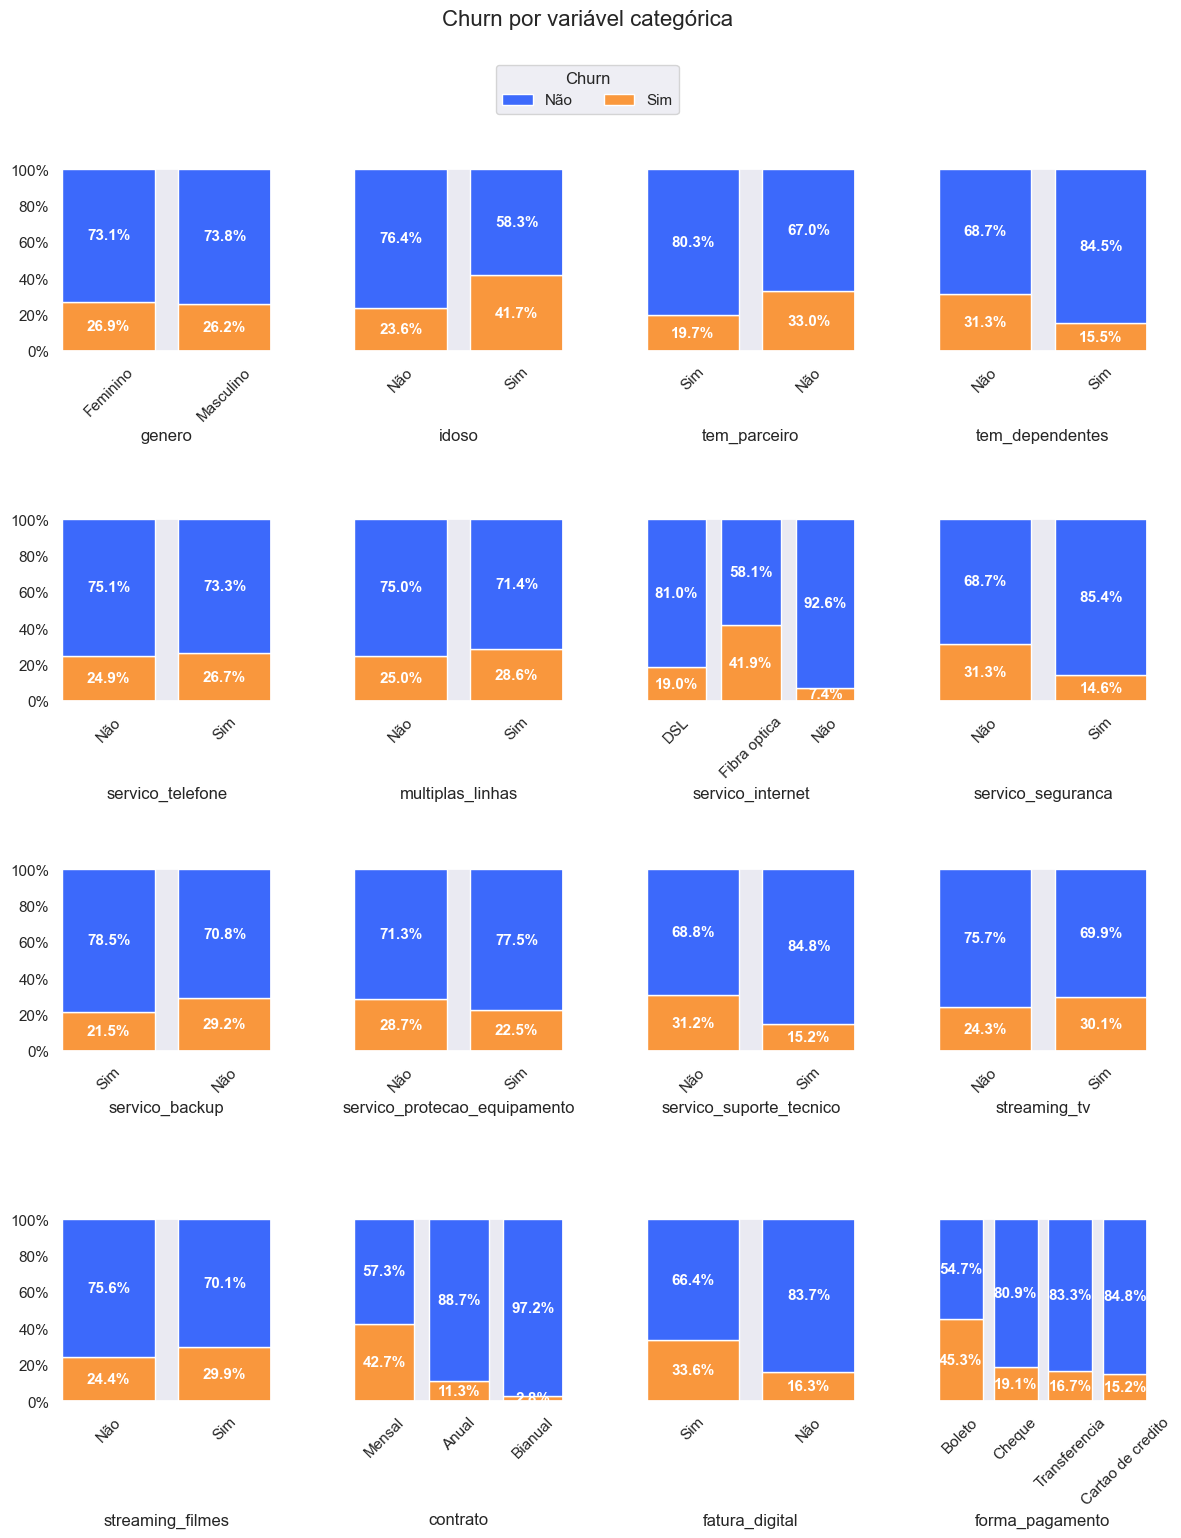

In [ ]:
from matplotlib.ticker import PercentFormatter
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 16), sharey=True)

for i, colunas in enumerate(colunas_categoricas):
    h = sns.histplot(x = colunas, hue = "churn", data=df_churn, ax = axs.flat[i], multiple="fill", stat="percent",
                 shrink=0.8);
    h.tick_params(axis="x",labelrotation = 45)
    legenda = axs.flat[i].get_legend()
    legenda.remove()

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')
    # Modifica a formatação do eixo y

    for bar in h.containers:
        h.bar_label(bar, label_type="center", labels=[f"{b.get_height():.1%}" for b in bar], color='white', weight='bold', fontsize=11)
    """
    pega cada barra e modifica os rótulos colocando eles no centro com a formatação de porcentagem
    """
rotulos_legenda = [texto.get_text() for texto in legenda.get_texts()]

fig.legend(handles=legenda.legend_handles, labels=rotulos_legenda, loc = "upper center", ncols = 2, title = "Churn", bbox_to_anchor = (0.5,0.95))
fig.suptitle("Churn por variável categórica\n\n", fontsize = 16)

fig.align_labels()
plt.subplots_adjust(wspace=0.4, hspace=0.925)
plt.show()